# Домашня робота №7

# Перетворення випадкових величин

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1 Квантильне перетворення

### 1.1 Нормальний розподіл

Нехай випадкова величина $\xi \sim N(0, 1)$.

Згенеруйте $n = 100000$ значень випадкової величини $\xi$ за допомогою квантильного перетворення.

Намалюйте нормовану гістограму отриманих $n = 100000$ значень випадкової величини $\xi$ разом з її функцією щільності.

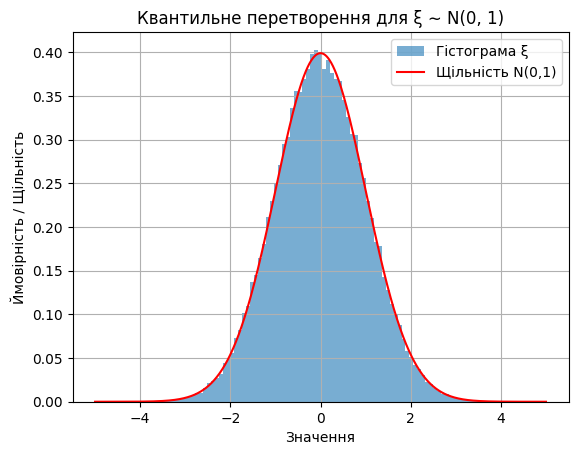

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 100000
u = np.random.uniform(0, 1, n)
xi = norm.ppf(u)

x = np.linspace(-5, 5, 1000)
pdf = norm.pdf(x)

plt.hist(xi, bins=100, density=True, alpha=0.6, label="Гістограма ξ")
plt.plot(x, pdf, 'r-', label="Щільність N(0,1)")
plt.title("Квантильне перетворення для ξ ∼ N(0, 1)")
plt.xlabel("Значення")
plt.ylabel("Ймовірність / Щільність")
plt.legend()
plt.grid(True)
plt.show()

## 2 Відсутність пам'яті

Розглянемо випадкову величину $\xi$ з геометричного розподілу з параметром $p = 0.5$.
Тобто $\xi \sim Geom(0.5)$.

1. Згенеруйте $n = 10000$ значень випадкової величини $\xi$;
2. Реалізуйте 2 сабплоти в одному рядку;
3. На першому сабплоті намалюйте:
   - нормовану гістограму згенерованих $n = 10000$ значень випадкової величини $\xi$;
   - функцію ймовірностей випадкової величини $\xi$;
4. Отримайте $n = 10000$ значень випадкової величини $\eta = (\xi - 1) I_{(\xi - 1) > 0}$;
5. На другому сабплоті намалюйте:
   - нормовану гістограму отриманих значень випадкової величини $\eta$;
   - функцію ймовірностей випадкової величини $\xi$.

**Зауваження 1.** Графік функції ймовірнстей краще малювати для $10$ значень.

**Зауваження 2.** У гістограмах проміжок значень слід розбивати на одиничні інтервали.

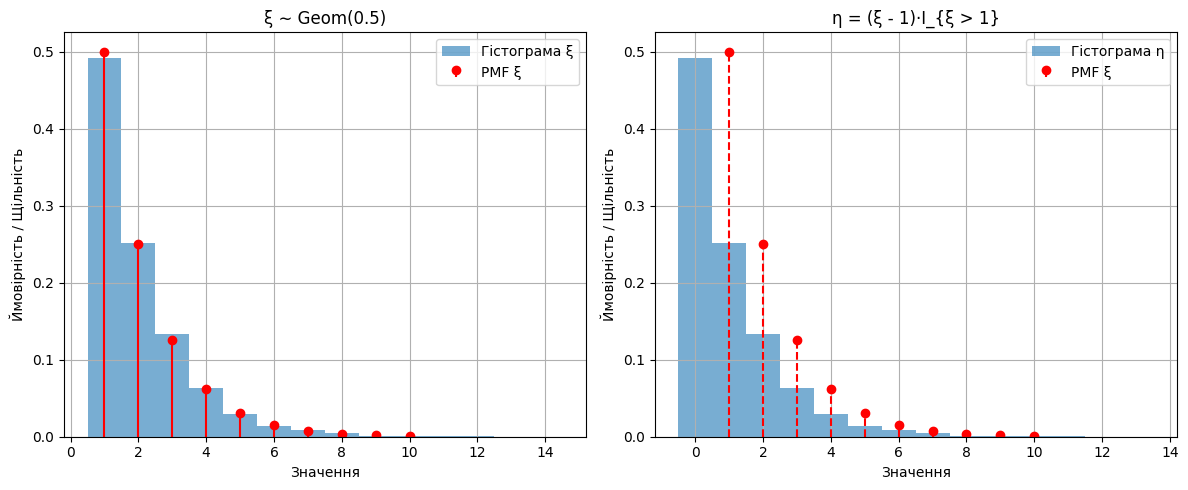

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

n = 10000
p = 0.5
xi = geom.rvs(p, size=n)
eta = (xi - 1) * (xi - 1 > 0)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

k_values = np.arange(1, 11)
pmf = geom.pmf(k_values, p)

axs[0].hist(xi, bins=np.arange(1, xi.max() + 2) - 0.5, density=True, alpha=0.6, label="Гістограма ξ")
axs[0].stem(k_values, pmf, linefmt='r-', markerfmt='ro', basefmt=" ", label="PMF ξ")
axs[0].set_title("ξ ∼ Geom(0.5)")
axs[0].set_xlabel("Значення")
axs[0].set_ylabel("Ймовірність / Щільність")
axs[0].legend()
axs[0].grid(True)

axs[1].hist(eta, bins=np.arange(0, eta.max() + 2) - 0.5, density=True, alpha=0.6, label="Гістограма η")
axs[1].stem(k_values, pmf, linefmt='r--', markerfmt='ro', basefmt=" ", label="PMF ξ")
axs[1].set_title("η = (ξ - 1)·I_{ξ > 1}")
axs[1].set_xlabel("Значення")
axs[1].set_ylabel("Ймовірність / Щільність")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 3 Задача 1.11.3

Розглянемо випадкову величину $\xi$ зі стандартного експоненційного розподілу.
Тобто $\xi \sim Exp(1)$.

**Текст, выделенный полужирным шрифтом**### 3.1 Квадрат

1. Згенеруйте $n = 10000$ значень випадкової величини $\xi$;
2. Реалізуйте 2 сабплоти в одному рядку;
3. На першому сабплоті намалюйте:
   - нормовану гістограму згенерованих $n = 10000$ значень випадкової величини $\xi$;
   - функцію щільності випадкової величини $\xi$;
4. Отримайте $n = 10000$ значень випадкової величини $\eta = \xi^2$ (застосуйте функцію модуль до згенерованих $n = 10000$ значень випадкової величини $\xi$);
5. На другому сабплоті намалюйте:
   - нормовану гістограму отриманих $n = 10000$ значень випадкової величини $\eta$;
   - функцію щільності випадкової величини $\xi$;
   - функцію щільності випадкової величини $\eta$.

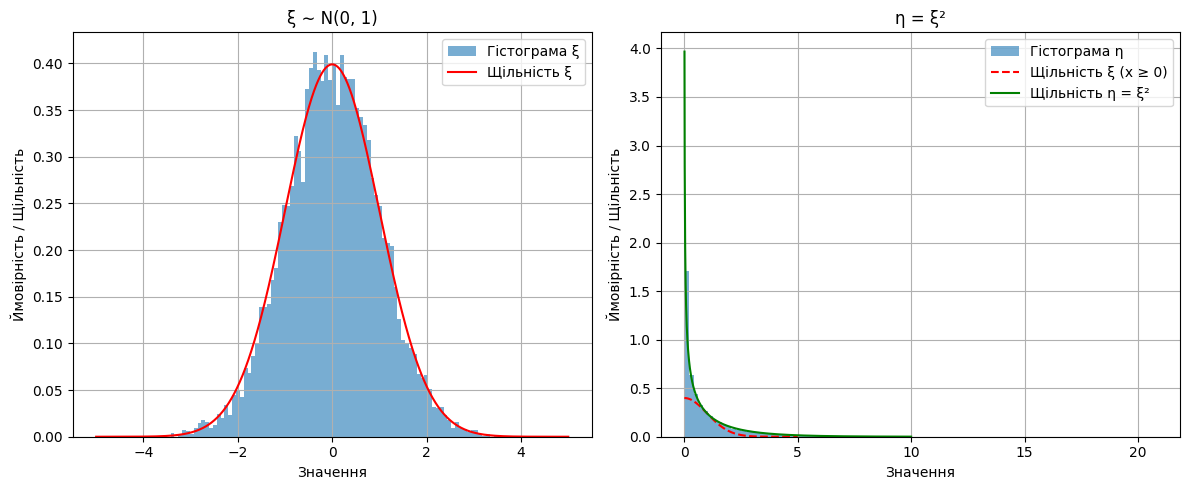

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

n = 10000
xi = norm.rvs(size=n)
eta = xi**2

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

x1 = np.linspace(-5, 5, 1000)
f_xi = norm.pdf(x1)

axs[0].hist(xi, bins=100, density=True, alpha=0.6, label="Гістограма ξ")
axs[0].plot(x1, f_xi, 'r-', label="Щільність ξ")
axs[0].set_title("ξ ∼ N(0, 1)")
axs[0].set_xlabel("Значення")
axs[0].set_ylabel("Ймовірність / Щільність")
axs[0].legend()
axs[0].grid(True)

x2 = np.linspace(0, 10, 1000)
f_eta = chi2.pdf(x2, df=1)

axs[1].hist(eta, bins=100, density=True, alpha=0.6, label="Гістограма η")
axs[1].plot(x1[x1 >= 0], f_xi[x1 >= 0], 'r--', label="Щільність ξ (x ≥ 0)")
axs[1].plot(x2, f_eta, 'g-', label="Щільність η = ξ²")
axs[1].set_title("η = ξ²")
axs[1].set_xlabel("Значення")
axs[1].set_ylabel("Ймовірність / Щільність")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 4 Одиничний квадрат

Реалізуйте випадкову величину рівномірно розподілену на одиничному квадраті.
Тобто $\xi = (x, y), \quad x, y \sim Unif(0, 1)$.

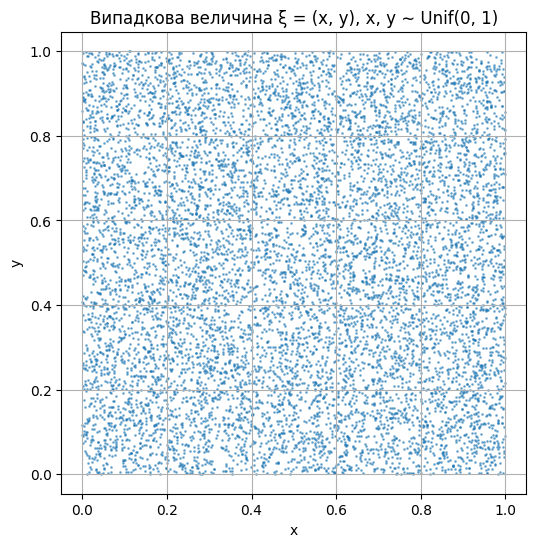

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000
x = np.random.uniform(0, 1, n)
y = np.random.uniform(0, 1, n)
xi = np.column_stack((x, y))

plt.figure(figsize=(6, 6))
plt.scatter(xi[:, 0], xi[:, 1], s=1, alpha=0.5)
plt.title("Випадкова величина ξ = (x, y), x, y ∼ Unif(0, 1)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axis("equal")
plt.show()

Знайдіть функцію щільності випадкової величини $\xi_3 = |x - y|$.
Намалюйте її разом із нормованою гістограмою $n = 100000$ значень випадкової величини $\xi_3$,
отриманою перетвореннями випадкових величин $x, y$.

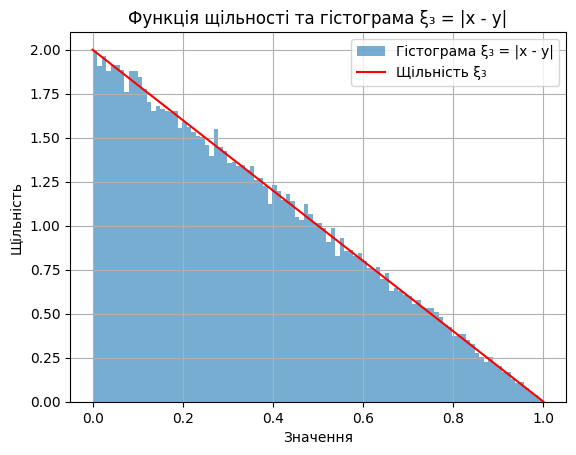

In [6]:
import numpy as np
import matplotlib.pyplot as plt

n = 100000
x = np.random.uniform(0, 1, n)
y = np.random.uniform(0, 1, n)
xi3 = np.abs(x - y)

def density_xi3(t):
    return 2 * (1 - t) * (0 <= t) * (t <= 1)

t = np.linspace(0, 1, 500)
f_t = density_xi3(t)

plt.hist(xi3, bins=100, density=True, alpha=0.6, label="Гістограма ξ₃ = |x - y|")
plt.plot(t, f_t, 'r-', label="Щільність ξ₃")
plt.title("Функція щільності та гістограма ξ₃ = |x - y|")
plt.xlabel("Значення")
plt.ylabel("Щільність")
plt.legend()
plt.grid(True)
plt.show()